In [ ]:
# /// script
# requires-python = ">=3.13"
# dependencies = [
#     "matplotlib>=3.10.8",
#     "pandas>=2.3.3",
#     "seaborn>=0.13.2",
#     "plotnine>=0.15.0",
#     "pygal>=3.0.5",
#     "pywaffle>=1.1.1",
#     "squarify>=0.4.4",
# ]
# ///

# MicroPython Board Trend Report

This notebook reads board metadata from the standalone reporting SQLite database (`reporting/micropython_boards_reporting.sqlite3`) and creates a dual-axis trend chart by version:
- stacked bars on the left axis: boards by port + board variants
- line graph on the right axis: unique ports

## Step-by-step
- Clone `mpflash`.
- Clone `micropython` into the repository `repos` folder.
- Run `reporting/build_reporting_db.py` to build or refresh the reporting database.
- Run this notebook to generate the charts and reports.

The horizontal axis shows versions from the reporting DB, excluding preview versions, `-rc1`, and patch versions where patch is not `0`.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

search_roots = [Path.cwd(), *Path.cwd().parents]
repo_root = next((path for path in search_roots if (path / "pyproject.toml").is_file()), None)
if repo_root is None:
    tried = "\n".join(str(path) for path in search_roots)
    raise FileNotFoundError(f"Could not determine repository root. Checked:\n{tried}")

reporting_db_path = (repo_root / "reporting/micropython_boards_reporting.sqlite3").resolve()
if not reporting_db_path.is_file():
    raise FileNotFoundError(f"Reporting database not found: {reporting_db_path}")

print(f"Using reporting database: {reporting_db_path}")

Using reporting database: C:\dev\mpflash\reporting\micropython_boards_reporting.sqlite3


In [41]:
import sqlite3

with sqlite3.connect(reporting_db_path) as conn:
    df_versions = pd.read_sql_query(
        """
        SELECT
            version_order,
            version,
            boards_found AS boards,
            board_variants_found AS variants,
            ports_found AS ports
        FROM version_stats
        ORDER BY version_order
        """,
        conn,
    )

    df_base_boards = pd.read_sql_query(
        """
        SELECT version, COALESCE(NULLIF(port, ''), '(no port)') AS port_group
        FROM board_rows
        WHERE variant = ''
        """,
        conn,
    )

if df_versions.empty:
    raise ValueError("No version statistics found in reporting database.")

# Omit preview releases and -rc1.
df_versions = df_versions[~df_versions["version"].str.contains("preview", case=False, na=False)].copy()
df_versions = df_versions[~df_versions["version"].str.contains(r"-rc1$", case=False, na=False, regex=True)].copy()

# Keep only major.minor and major.minor.0 (omit patch where patch != 0).
patch_part = df_versions["version"].str.extract(r"^v?\d+\.\d+(?:\.(\d+))?")[0]
patch_num = pd.to_numeric(patch_part, errors="coerce").fillna(0).astype(int)
df_versions = df_versions[patch_num == 0].copy()

# Keep board-by-port rows aligned with displayed versions only.
df_base_boards = df_base_boards[df_base_boards["version"].isin(df_versions["version"])].copy()

df_boards_by_port = (
    df_base_boards.groupby(["version", "port_group"]).size().unstack(fill_value=0).reindex(df_versions["version"], fill_value=0)
)
port_columns = df_boards_by_port.sum().sort_values(ascending=False).index.tolist()
df_boards_by_port = df_boards_by_port[port_columns]

df_versions

,version_order,version,boards,variants,ports
1,1,v1.0,9,0,2
3,3,v1.1,6,0,1
5,5,v1.2,6,0,1
6,6,v1.3,6,0,1
17,17,v1.4,10,0,2
24,24,v1.5,12,0,2
27,27,v1.6,16,0,2
28,28,v1.7,18,0,2
29,29,v1.8,19,0,2
37,37,v1.9,24,0,2


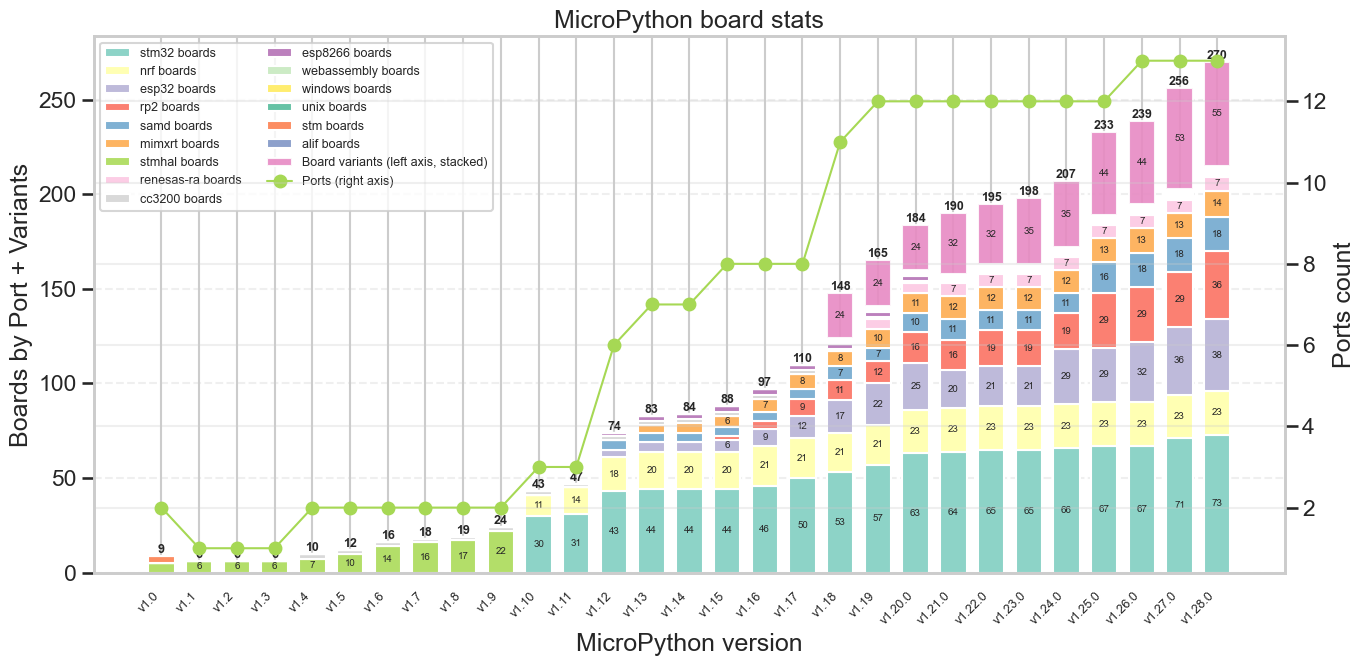

In [57]:
x = range(len(df_versions))

fig, ax_left = plt.subplots(figsize=(14, 7))
ax_right = ax_left.twinx()

palette = list(plt.cm.Set3.colors) + list(plt.cm.Set2.colors) + list(plt.cm.tab20.colors)


def version_tuple(version: str) -> tuple[int, int, int]:
    parts = version.lstrip("v").split(".")
    major = int(parts[0]) if len(parts) > 0 else 0
    minor = int(parts[1]) if len(parts) > 1 else 0
    patch = int(parts[2]) if len(parts) > 2 else 0
    return (major, minor, patch)


bottom = pd.Series([0] * len(df_versions), dtype="float64")
for idx, port_name in enumerate(port_columns):
    values = df_boards_by_port[port_name].to_numpy()
    color = palette[idx % len(palette)]
    segment_bottom = bottom.to_numpy().copy()
    ax_left.bar(
        x,
        values,
        width=0.7,
        bottom=segment_bottom,
        color=color,
        label=f"{port_name} boards",
    )
    for xi, value, base in zip(x, values, segment_bottom):
        if value > 5:
            ax_left.text(
                xi,
                base + (value / 2),
                f"{int(value)}",
                ha="center",
                va="center",
                fontsize=7,
            )
    bottom = bottom + values

board_totals = bottom.to_numpy()
variant_values = df_versions["variants"].to_numpy()
stack_totals = board_totals + variant_values

variants_color = palette[len(port_columns) % len(palette)]
line_color = palette[(len(port_columns) + 1) % len(palette)]

ax_left.bar(
    x,
    variant_values,
    width=0.7,
    bottom=board_totals,
    color=variants_color,
    alpha=0.9,
    label="Board variants (left axis, stacked)",
)

ax_right.plot(
    x,
    df_versions["ports"],
    color=line_color,
    marker="o",
    linewidth=1.5,
    label="Ports (right axis)",
)

ax_left.set_xticks(list(x))
ax_left.set_xticklabels(df_versions["version"], rotation=45, ha="right", fontsize=9)
ax_left.set_ylabel("Boards by Port + Variants")
ax_right.set_ylabel("Ports count")
ax_left.set_xlabel("MicroPython version")
ax_left.set_title("MicroPython board stats")
ax_left.grid(axis="y", linestyle="--", alpha=0.3)
ax_right.grid(axis="y", alpha=0.3)

# Labels: variant count from v1.18 onward and total stack count on top.
for xi, version, boards, variants, total in zip(x, df_versions["version"], board_totals, variant_values, stack_totals):
    if variants > 0 and version_tuple(version) >= (1, 18, 0):
        ax_left.text(
            xi,
            boards + (variants / 2),
            f"{int(variants)}",
            ha="center",
            va="center",
            fontsize=7,
        )
    ax_left.text(xi, total, f"{int(total)}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# for xi, ports in zip(x, df_versions["ports"]):
#     ax_right.text(xi, ports, f"{int(ports)}", ha="center", va="bottom", fontsize=12)

left_handles, left_labels = ax_left.get_legend_handles_labels()
right_handles, right_labels = ax_right.get_legend_handles_labels()
ax_left.legend(
    left_handles + right_handles,
    left_labels + right_labels,
    loc="upper left",
    fontsize=9,
    ncol=2,
)

plt.tight_layout()
plt.show()

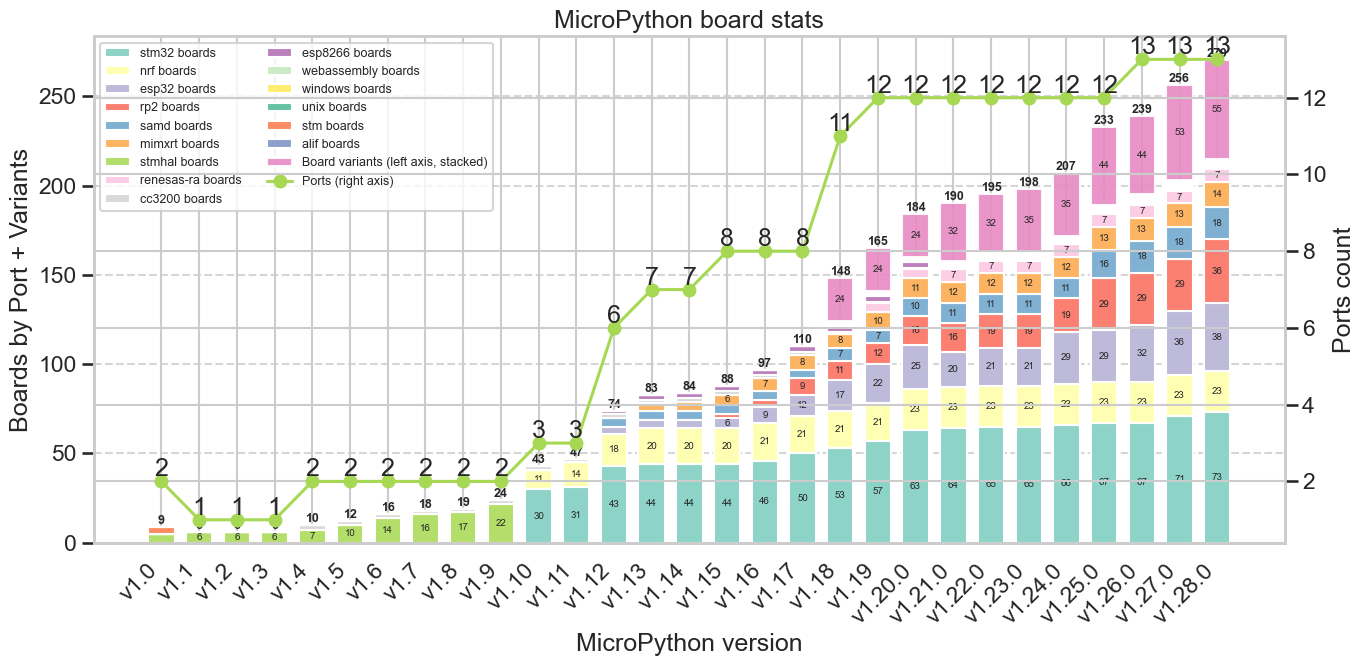

In [52]:
x = range(len(df_versions))

fig, ax_left = plt.subplots(figsize=(14, 7))
ax_right = ax_left.twinx()

palette = list(plt.cm.Set3.colors) + list(plt.cm.Set2.colors) + list(plt.cm.tab20.colors)


def version_tuple(version: str) -> tuple[int, int, int]:
    parts = version.lstrip("v").split(".")
    major = int(parts[0]) if len(parts) > 0 else 0
    minor = int(parts[1]) if len(parts) > 1 else 0
    patch = int(parts[2]) if len(parts) > 2 else 0
    return (major, minor, patch)


bottom = pd.Series([0] * len(df_versions), dtype="float64")
for idx, port_name in enumerate(port_columns):
    values = df_boards_by_port[port_name].to_numpy()
    color = palette[idx % len(palette)]
    segment_bottom = bottom.to_numpy().copy()
    ax_left.bar(
        x,
        values,
        width=0.7,
        bottom=segment_bottom,
        color=color,
        label=f"{port_name} boards",
    )
    for xi, value, base in zip(x, values, segment_bottom):
        if value > 5:
            ax_left.text(
                xi,
                base + (value / 2),
                f"{int(value)}",
                ha="center",
                va="center",
                fontsize=7,
            )
    bottom = bottom + values

board_totals = bottom.to_numpy()
variant_values = df_versions["variants"].to_numpy()
stack_totals = board_totals + variant_values

variants_color = palette[len(port_columns) % len(palette)]
line_color = palette[(len(port_columns) + 1) % len(palette)]

ax_left.bar(
    x,
    variant_values,
    width=0.7,
    bottom=board_totals,
    color=variants_color,
    alpha=0.9,
    label="Board variants (left axis, stacked)",
)

ax_right.plot(
    x,
    df_versions["ports"],
    color=line_color,
    marker="o",
    linewidth=2.2,
    label="Ports (right axis)",
)

ax_left.set_xticks(list(x))
ax_left.set_xticklabels(df_versions["version"], rotation=45, ha="right")
ax_left.set_ylabel("Boards by Port + Variants")
ax_right.set_ylabel("Ports count")
ax_left.set_xlabel("MicroPython version")
ax_left.set_title("MicroPython board stats")
ax_left.grid(axis="y", linestyle="--", alpha=0.8)

# Labels: variant count from v1.18 onward and total stack count on top.
for xi, version, boards, variants, total in zip(x, df_versions["version"], board_totals, variant_values, stack_totals):
    if variants > 0 and version_tuple(version) >= (1, 18, 0):
        ax_left.text(
            xi,
            boards + (variants / 2),
            f"{int(variants)}",
            ha="center",
            va="center",
            fontsize=7,
        )
    ax_left.text(xi, total, f"{int(total)}", ha="center", va="bottom", fontsize=9, fontweight="bold")

for xi, ports in zip(x, df_versions["ports"]):
    ax_right.text(xi, ports, f"{int(ports)}", ha="center", va="bottom")

left_handles, left_labels = ax_left.get_legend_handles_labels()
right_handles, right_labels = ax_right.get_legend_handles_labels()
ax_left.legend(
    left_handles + right_handles,
    left_labels + right_labels,
    loc="upper left",
    fontsize=9,
    ncol=2,
)

plt.tight_layout()
plt.show()

## Alternative Report: Port Evolution Heatmap

This report shows the same dataset in a different form.

It combines:
- a heatmap of board counts per port across versions
- a compact bar chart for the latest visible version
- a line chart comparing total boards and variants over time

This makes it easier to see when specific ports accelerate, flatten, or fall behind.

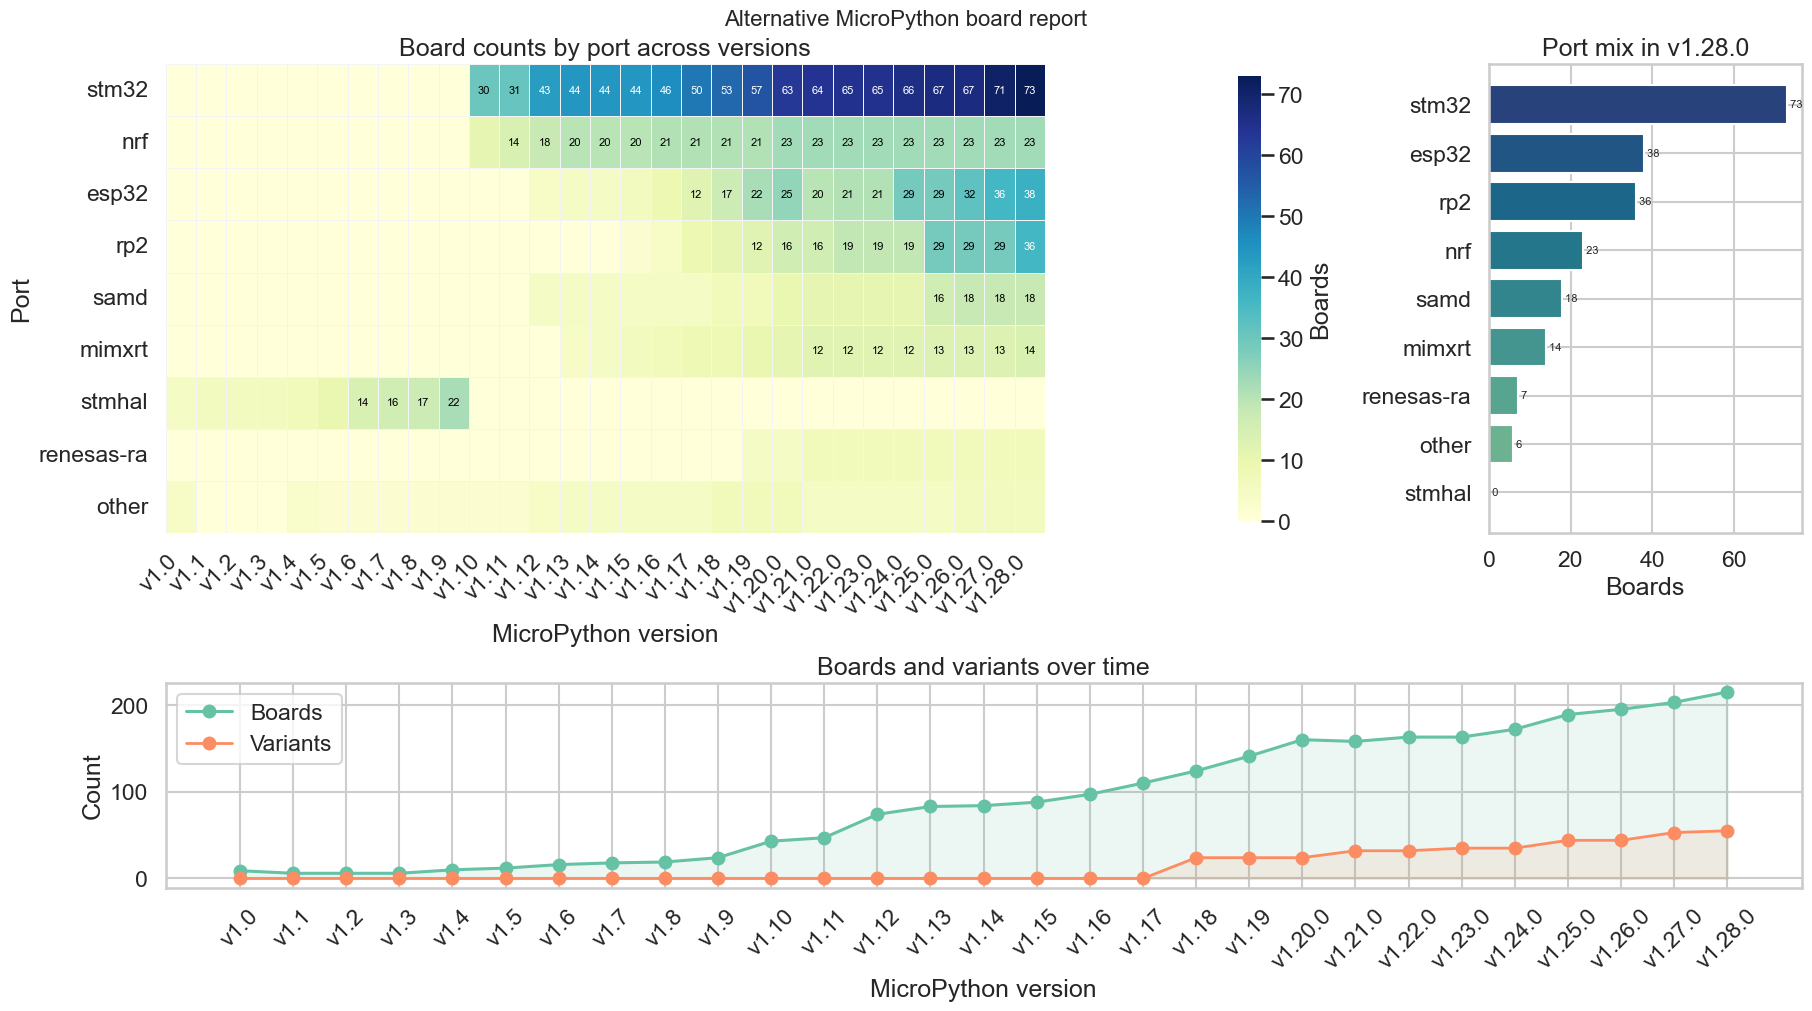

In [44]:
import seaborn as sns

top_port_count = 8

heatmap_source = df_boards_by_port.copy()
if heatmap_source.empty:
    raise ValueError("No board-by-port data available for the alternative report.")

top_ports = heatmap_source.sum().sort_values(ascending=False).head(top_port_count).index.tolist()
other_ports = [port for port in heatmap_source.columns if port not in top_ports]

heatmap_df = heatmap_source[top_ports].copy()
if other_ports:
    heatmap_df["other"] = heatmap_source[other_ports].sum(axis=1)

heatmap_matrix = heatmap_df.transpose()
versions = df_versions["version"].tolist()
latest_version = versions[-1]

sns.set_theme(style="whitegrid", context="talk")

fig = plt.figure(figsize=(18, 10), constrained_layout=True)
grid = fig.add_gridspec(
    nrows=2,
    ncols=2,
    height_ratios=[3.2, 1.4],
    width_ratios=[4.5, 1.6],
)

ax_heatmap = fig.add_subplot(grid[0, 0])
sns.heatmap(
    heatmap_matrix,
    ax=ax_heatmap,
    cmap="YlGnBu",
    linewidths=0.4,
    linecolor="#f3f4f6",
    cbar_kws={"label": "Boards", "shrink": 0.95},
)
ax_heatmap.set_title("Board counts by port across versions")
ax_heatmap.set_xlabel("MicroPython version")
ax_heatmap.set_ylabel("Port")
ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(), rotation=45, ha="right")

max_value = int(heatmap_matrix.to_numpy().max()) if not heatmap_matrix.empty else 0
label_threshold = max(6, max_value // 6 if max_value else 6)
for row_index, port_name in enumerate(heatmap_matrix.index):
    for col_index, version in enumerate(versions):
        value = int(heatmap_matrix.loc[port_name, version])
        if value >= label_threshold:
            text_color = "white" if value > max_value * 0.45 else "black"
            ax_heatmap.text(
                col_index + 0.5,
                row_index + 0.5,
                str(value),
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
            )

ax_latest = fig.add_subplot(grid[0, 1])
latest_counts = heatmap_df.loc[latest_version].sort_values(ascending=True)
latest_colors = sns.color_palette("crest", n_colors=len(latest_counts))
ax_latest.barh(latest_counts.index, latest_counts.values, color=latest_colors)
ax_latest.set_title(f"Port mix in {latest_version}")
ax_latest.set_xlabel("Boards")
for index, value in enumerate(latest_counts.values):
    ax_latest.text(value, index, f" {int(value)}", va="center", fontsize=8)

ax_trend = fig.add_subplot(grid[1, :])
trend_palette = sns.color_palette("Set2", n_colors=2)
ax_trend.plot(
    versions,
    df_versions["boards"],
    marker="o",
    linewidth=2.2,
    color=trend_palette[0],
    label="Boards",
)
ax_trend.plot(
    versions,
    df_versions["variants"],
    marker="o",
    linewidth=2.0,
    color=trend_palette[1],
    label="Variants",
)
ax_trend.fill_between(
    versions,
    df_versions["boards"],
    alpha=0.12,
    color=trend_palette[0],
)
ax_trend.fill_between(
    versions,
    df_versions["variants"],
    alpha=0.12,
    color=trend_palette[1],
)
ax_trend.set_title("Boards and variants over time")
ax_trend.set_ylabel("Count")
ax_trend.set_xlabel("MicroPython version")
ax_trend.legend(loc="upper left")
ax_trend.tick_params(axis="x", rotation=45)

fig.suptitle("Alternative MicroPython board report", fontsize=16)
plt.show()

## Additional Report Options

The following views present the same reporting-database data with different visual grammars:
- a plotnine stacked area chart for port share over time
- a pygal donut chart for the latest version as a parts-of-whole SVG
- a seaborn ranking heatmap to show the strongest ports by version
- a PyWaffle chart for the latest version as a square-based parts-of-whole view

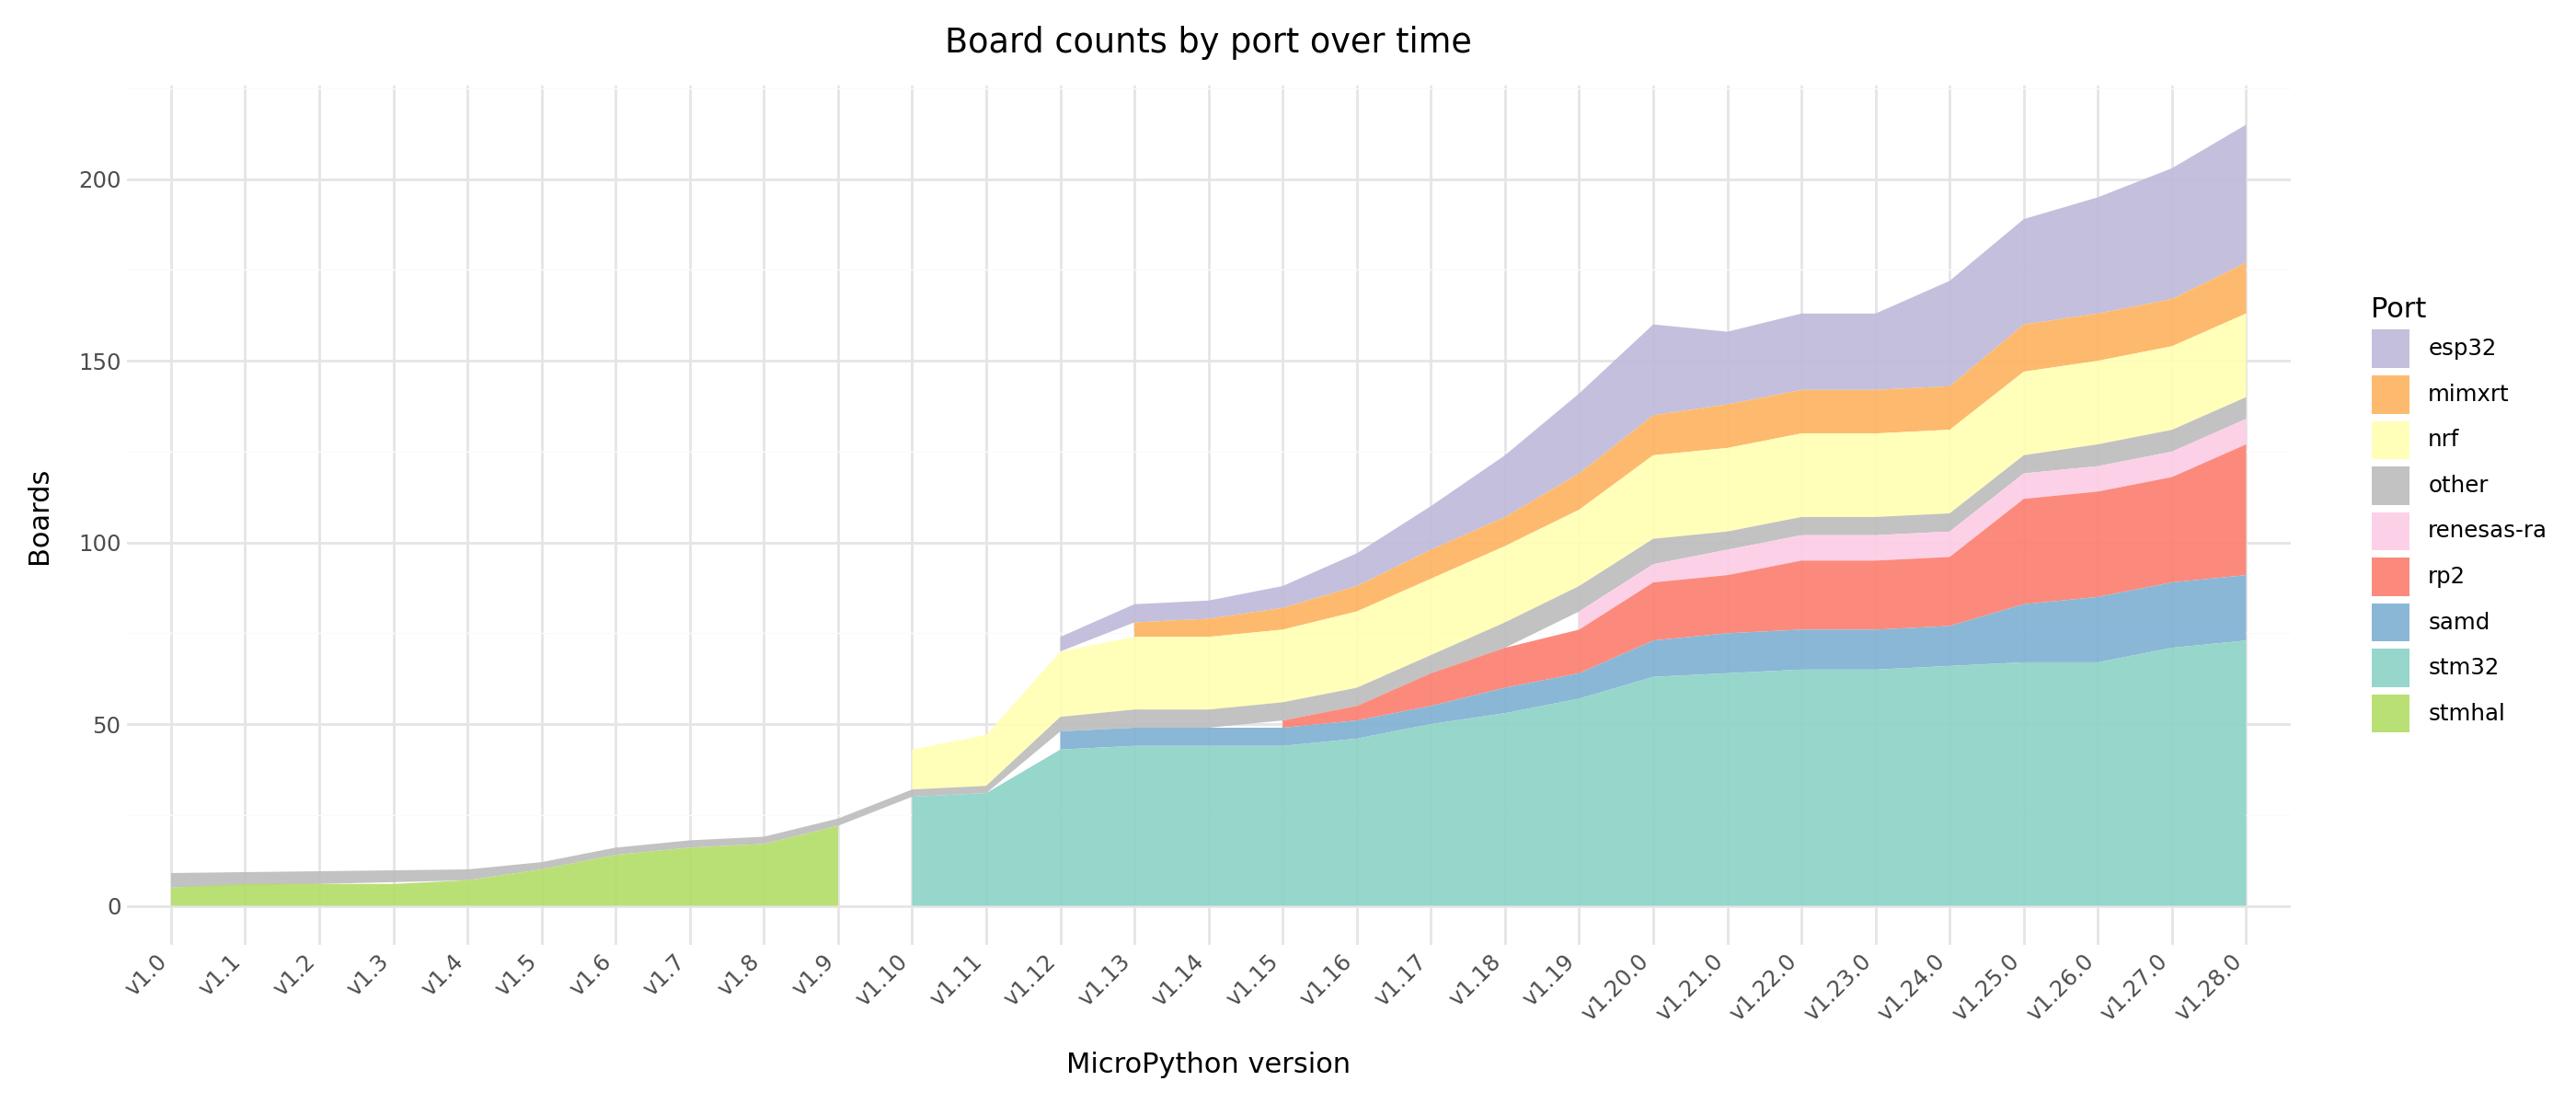

In [ ]:
from plotnine import aes, geom_area, ggplot, labs, scale_fill_manual, theme_minimal, theme, element_text

plotnine_source = df_boards_by_port.copy()
plotnine_top_ports = plotnine_source.sum().sort_values(ascending=False).head(8).index.tolist()
plotnine_other_ports = [port for port in plotnine_source.columns if port not in plotnine_top_ports]

plotnine_df = plotnine_source[plotnine_top_ports].copy()
if plotnine_other_ports:
    plotnine_df["other"] = plotnine_source[plotnine_other_ports].sum(axis=1)

plotnine_df["version"] = pd.Categorical(
    df_versions["version"].values,
    categories=df_versions["version"].tolist(),
    ordered=True,
)

plotnine_long = plotnine_df.melt(
    id_vars=["version"],
    var_name="port",
    value_name="boards",
)
plotnine_long = plotnine_long[plotnine_long["boards"] > 0].copy()

plotnine_palette = sns.color_palette("Set3", n_colors=len(plotnine_df.columns) - 1).as_hex()
plotnine_colors = {port: color for port, color in zip(plotnine_df.columns[:-1], plotnine_palette)}
if "other" in plotnine_df.columns:
    plotnine_colors["other"] = "#bdbdbd"

absolute_plot = (
    ggplot(plotnine_long, aes(x="version", y="boards", fill="port", group="port"))
    + geom_area(position="stack", alpha=0.92)
    + labs(
        title="Board counts by port over time",
        x="MicroPython version",
        y="Boards",
        fill="Port",
    )
    + scale_fill_manual(values=plotnine_colors)
    + theme_minimal()
    + theme(
        figure_size=(14, 6),
        axis_text_x=element_text(rotation=45, ha="right"),
        legend_position="right",
    )
)

absolute_plot

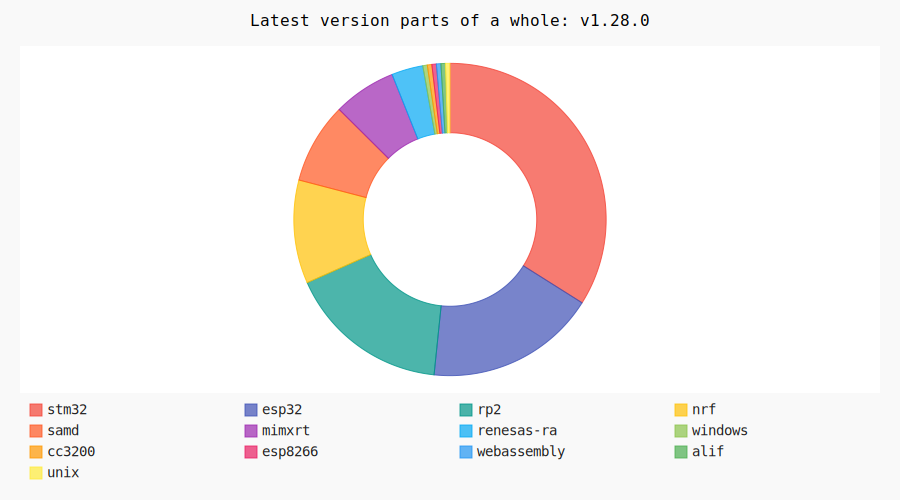

In [46]:
import pygal
from IPython.display import SVG, display

latest_port_mix = df_boards_by_port.loc[df_versions["version"].iloc[-1]].sort_values(ascending=False)
latest_port_mix = latest_port_mix[latest_port_mix > 0]

donut_chart = pygal.Pie(
    inner_radius=0.5,
    legend_at_bottom=True,
    truncate_legend=-1,
    show_legend=True,
    show_tooltip=True,
    width=900,
    height=500,
)
donut_chart.title = f"Latest version parts of a whole: {df_versions['version'].iloc[-1]}"
for port_name, value in latest_port_mix.items():
    donut_chart.add(port_name, int(value))

display(SVG(donut_chart.render()))

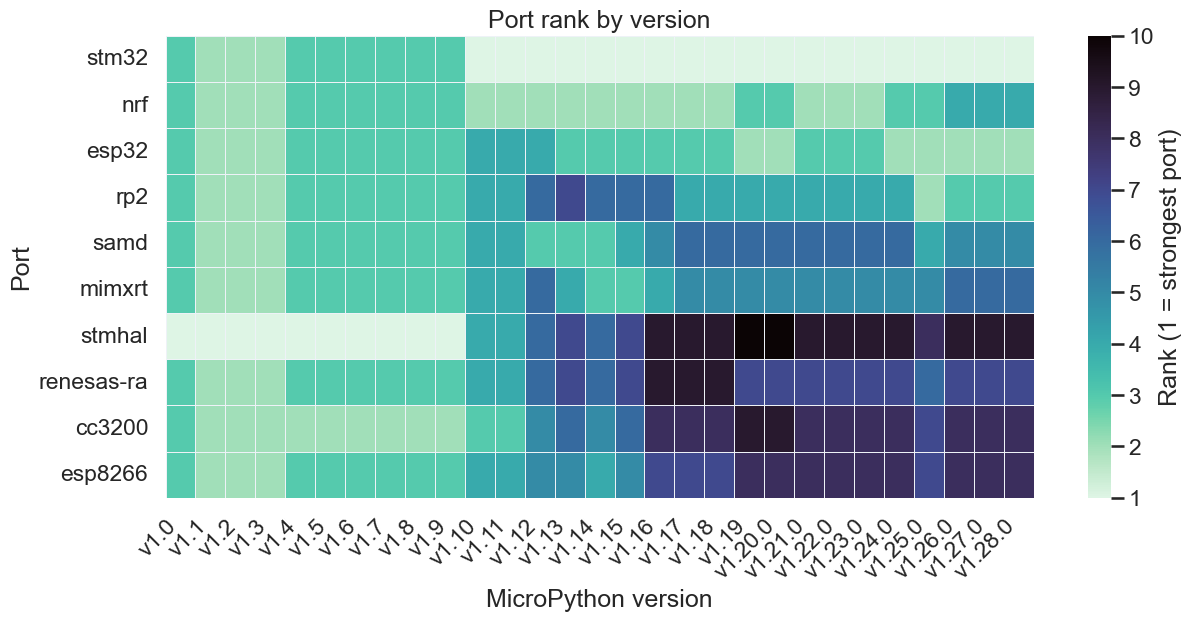

In [47]:
rank_df = df_boards_by_port.rank(axis=1, ascending=False, method="dense")
rank_df = rank_df[port_columns[:10]].transpose()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    rank_df,
    cmap="mako_r",
    linewidths=0.4,
    linecolor="#eef2f7",
    cbar_kws={"label": "Rank (1 = strongest port)"},
    ax=ax,
)
ax.set_title("Port rank by version")
ax.set_xlabel("MicroPython version")
ax.set_ylabel("Port")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.show()

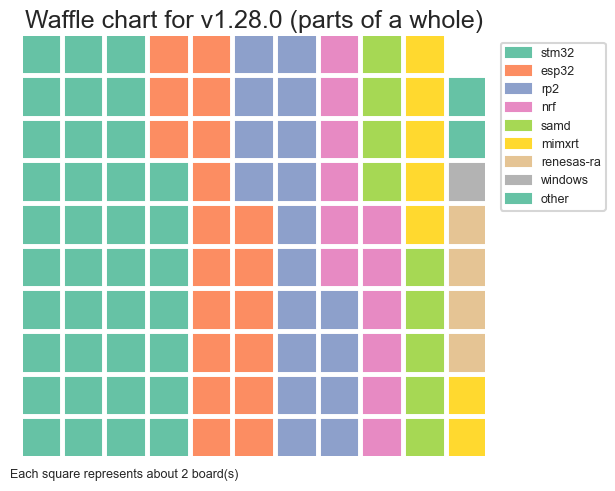

In [48]:
from pywaffle import Waffle

waffle_values = latest_port_mix.head(8).copy()
if len(latest_port_mix) > 8:
    waffle_values.loc["other"] = latest_port_mix.iloc[8:].sum()

waffle_colors = sns.color_palette("Set2", n_colors=len(waffle_values)).as_hex()
waffle_total = int(waffle_values.sum())
waffle_scale = max(1, round(waffle_total / 120))
scaled_values = {name: max(1, int(round(value / waffle_scale))) for name, value in waffle_values.items()}

fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    columns=sum(scaled_values.values()) // 10 + (1 if sum(scaled_values.values()) % 10 else 0),
    values=scaled_values,
    colors=waffle_colors,
    legend={
        "loc": "upper left",
        "bbox_to_anchor": (1.02, 1.0),
        "fontsize": 9,
    },
    figsize=(14, 5),
)
plt.title(f"Waffle chart for {df_versions['version'].iloc[-1]} (parts of a whole)")
plt.figtext(
    0.01,
    0.01,
    f"Each square represents about {waffle_scale} board(s)",
    ha="left",
    fontsize=9,
)
plt.show()

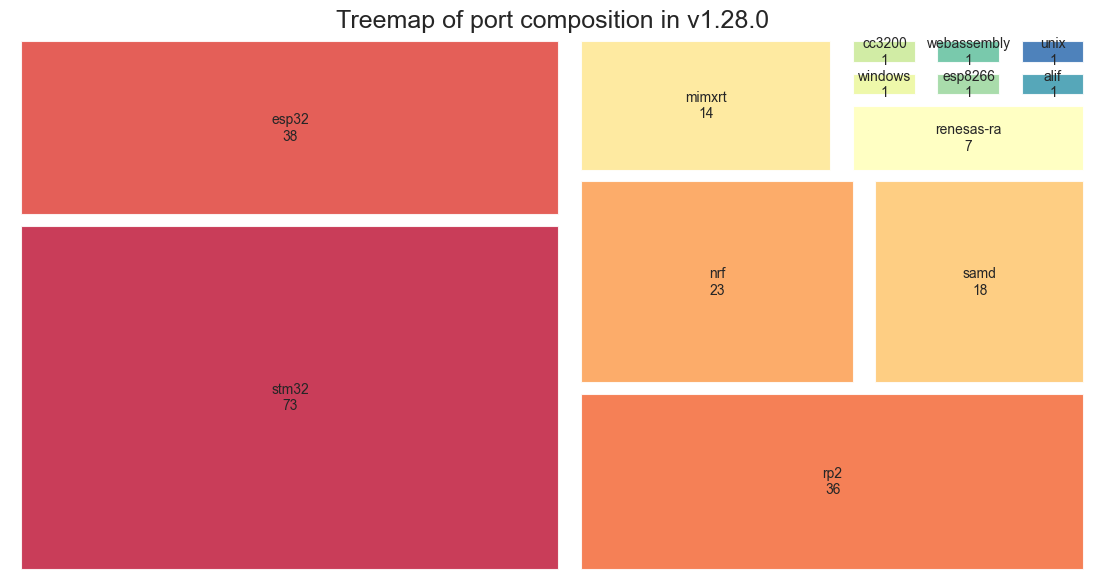

In [49]:
import squarify

treemap_values = latest_port_mix.copy()
treemap_labels = [f"{port}\n{int(value)}" for port, value in treemap_values.items()]
treemap_colors = sns.color_palette("Spectral", n_colors=len(treemap_values)).as_hex()

fig, ax = plt.subplots(figsize=(14, 7))
squarify.plot(
    sizes=treemap_values.values,
    label=treemap_labels,
    color=treemap_colors,
    alpha=0.92,
    pad=True,
    ax=ax,
    text_kwargs={"fontsize": 10},
)
ax.set_title(f"Treemap of port composition in {df_versions['version'].iloc[-1]}")
ax.axis("off")
plt.show()

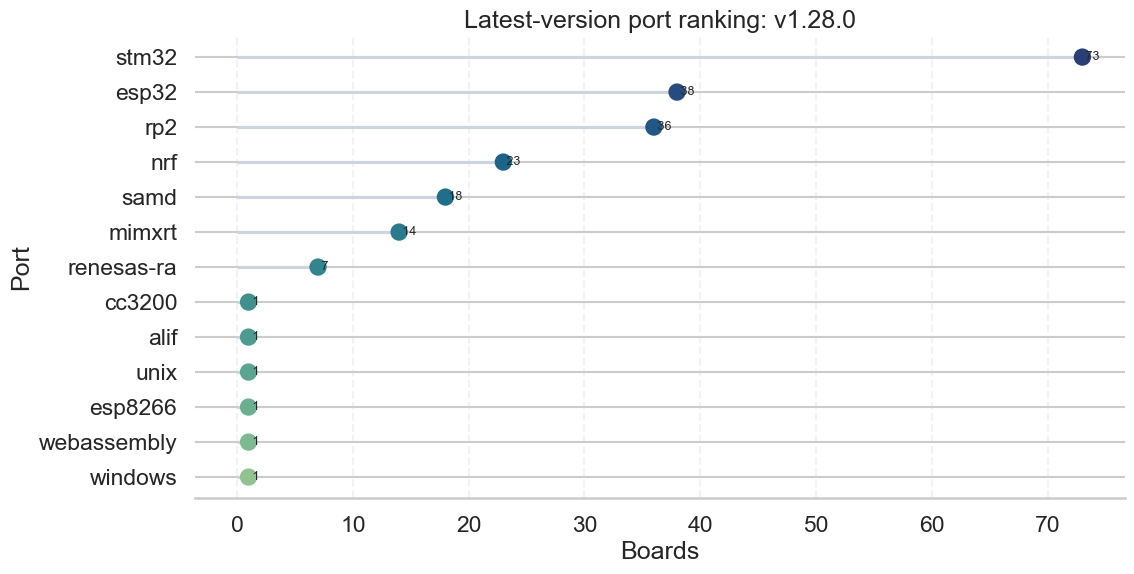

In [50]:
lollipop_counts = latest_port_mix.sort_values(ascending=True)
lollipop_colors = sns.color_palette("crest", n_colors=len(lollipop_counts))

fig, ax = plt.subplots(figsize=(12, 6))
ax.hlines(
    y=lollipop_counts.index,
    xmin=0,
    xmax=lollipop_counts.values,
    color="#cbd5e1",
    linewidth=2.2,
)
ax.scatter(
    lollipop_counts.values,
    lollipop_counts.index,
    s=120,
    color=lollipop_colors,
    zorder=3,
)
for port_name, value in lollipop_counts.items():
    ax.text(value, port_name, f" {int(value)}", va="center", fontsize=9)

ax.set_title(f"Latest-version port ranking: {df_versions['version'].iloc[-1]}")
ax.set_xlabel("Boards")
ax.set_ylabel("Port")
ax.grid(axis="x", linestyle="--", alpha=0.25)
sns.despine(left=True, bottom=False)
plt.show()

## Violin Plot Report

This view shows the distribution of board counts across active ports for each MicroPython version. Versions are ordered chronologically from top to bottom, so the shape of each violin highlights how concentrated or spread the port counts are in that release.

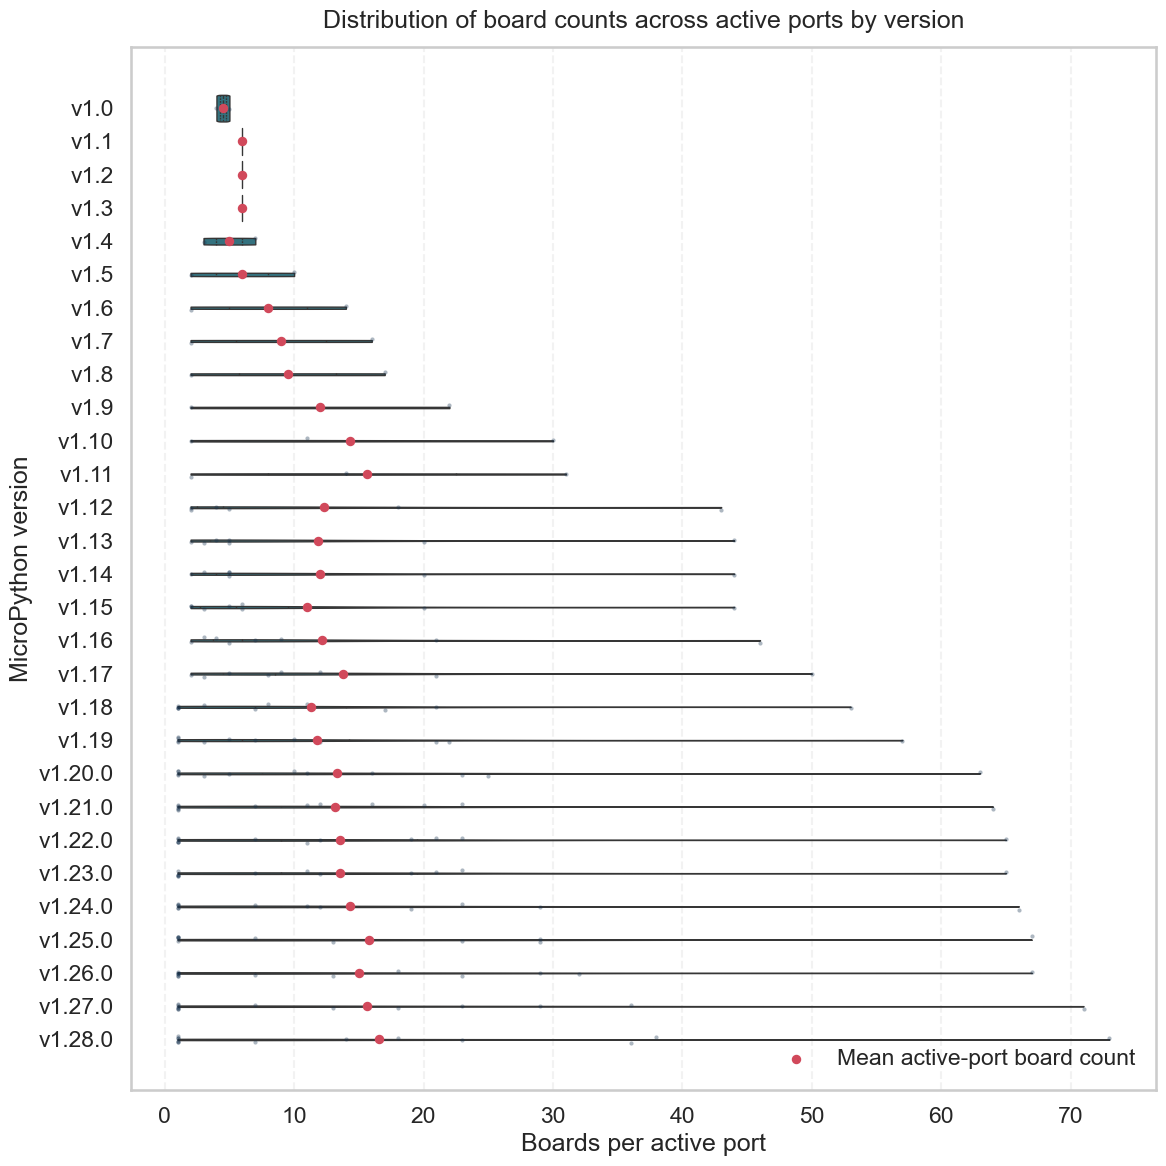

In [ ]:
violin_df = df_boards_by_port.reset_index().melt(id_vars="version", var_name="port", value_name="board_count").query("board_count > 0")

version_order = df_versions["version"].tolist()
mean_counts = violin_df.groupby("version", sort=False)["board_count"].mean().reindex(version_order)

fig, ax = plt.subplots(figsize=(12, 12))
base_color = sns.color_palette("crest", 6)[3]

sns.violinplot(
    data=violin_df,
    x="board_count",
    y="version",
    order=version_order,
    orient="h",
    inner="quart",
    cut=0,
    bw_adjust=0.8,
    linewidth=1,
    color=base_color,
    ax=ax,
)

sns.stripplot(
    data=violin_df,
    x="board_count",
    y="version",
    order=version_order,
    orient="h",
    size=3,
    alpha=0.35,
    color="#16324f",
    ax=ax,
)

ax.scatter(
    mean_counts.values,
    version_order,
    s=28,
    color="#d1495b",
    zorder=4,
    label="Mean active-port board count",
)

ax.set_title("Distribution of board counts across active ports by version", pad=14)
ax.set_xlabel("Boards per active port")
ax.set_ylabel("MicroPython version")
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()